<a href="https://colab.research.google.com/github/anushriadapawar/Admin-Building-Weekend-Dip/blob/main/Admin_Building_Weekend_Dip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Settings
sns.set_context("notebook")
plt.style.use("default")

In [38]:
df = pd.read_csv("energydata_complete.csv")
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [39]:
df['date'] = pd.to_datetime(df['date'])

df['hour'] = df['date'].dt.hour
df['weekday'] = df['date'].dt.weekday
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)

In [40]:
cluster_features = [
    'Appliances', 'lights', 'hour',
    'weekday', 'is_weekend',
    'T_out', 'RH_out', 'Windspeed'
]

scaler = StandardScaler()
scaled = scaler.fit_transform(df[cluster_features])

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled)

df.groupby('cluster')[['Appliances','lights','is_weekend']].mean()

,Appliances,lights,is_weekend
cluster,,,
0,61.545242,0.898471,0.252443
1,113.189522,0.942709,0.340384
2,169.949686,18.817610,0.209119


In [41]:
df['Appliances_lag1'] = df['Appliances'].shift(1)
df['Appliances_lag2'] = df['Appliances'].shift(2)
df['Appliances_lag3'] = df['Appliances'].shift(3)

In [42]:
# Cyclical hour encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Rolling statistics
df['Appliances_roll_mean_3'] = (
    df['Appliances'].rolling(3).mean().shift(1)
)

df['Appliances_roll_std_3'] = (
    df['Appliances'].rolling(3).std().shift(1)
)

df.dropna(inplace=True)

# Drop NaNs created by lag/rolling
df.dropna(inplace=True)

In [43]:
baseline_results = {}

for c in df['cluster'].unique():
    temp = df[df['cluster'] == c]

    X = temp[['hour','weekday','T_out','RH_out','Windspeed']]
    y = temp['Appliances']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    model = LinearRegression()
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    baseline_results[c] = {
        'MAE': mean_absolute_error(y_test, pred),
        'R2': r2_score(y_test, pred)
    }

baseline_results

{np.int32(2): {'MAE': 101.52648032395845, 'R2': 0.05942924731866428},
 np.int32(0): {'MAE': 16.451257515588175, 'R2': 0.03343104795281482},
 np.int32(1): {'MAE': 62.95862286150152, 'R2': -0.013578348975689991}}

In [44]:
final_features = [
    'hour_sin','hour_cos','is_weekend',
    'T_out','RH_out','Windspeed',
    'Appliances_lag1','Appliances_lag2','Appliances_lag3',
    'Appliances_roll_mean_3','Appliances_roll_std_3'
]

gb_models = {}
gb_results = {}

for c in df['cluster'].unique():
    temp = df[df['cluster'] == c]

    X = temp[final_features]
    y = temp['Appliances']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    model = HistGradientBoostingRegressor(
        max_depth=8,
        learning_rate=0.05,
        max_iter=300,
        random_state=42
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    gb_models[c] = model
    gb_results[c] = {
        'MAE': mean_absolute_error(y_test, pred),
        'R2': r2_score(y_test, pred)
    }

gb_results

{np.int32(2): {'MAE': 52.163927960249474, 'R2': 0.6230515939891527},
 np.int32(0): {'MAE': 13.065022288708104, 'R2': 0.3418396034192016},
 np.int32(1): {'MAE': 38.243026025904584, 'R2': 0.5339042303151327}}

In [45]:
comparison = pd.DataFrame({
    'Linear_MAE': {k:v['MAE'] for k,v in baseline_results.items()},
    'Linear_R2':  {k:v['R2'] for k,v in baseline_results.items()},
    'GB_MAE':     {k:v['MAE'] for k,v in gb_results.items()},
    'GB_R2':      {k:v['R2'] for k,v in gb_results.items()}
})

comparison

,Linear_MAE,Linear_R2,GB_MAE,GB_R2
2,101.526480,0.059429,52.163928,0.623052
0,16.451258,0.033431,13.065022,0.341840
1,62.958623,-0.013578,38.243026,0.533904


In [46]:
df['predicted'] = np.nan

for c in gb_models:
    idx = df['cluster'] == c
    df.loc[idx, 'predicted'] = gb_models[c].predict(
        df.loc[idx, final_features]
    )

df['savings'] = df['predicted'] - df['Appliances']
df['savings'] = df['savings'].apply(lambda x: x if x > 0 else 0)

In [47]:
savings_cluster = df.groupby('cluster')['savings'].sum()
savings_cluster

,savings
cluster,
0,50753.597383
1,85982.626509
2,65039.104724


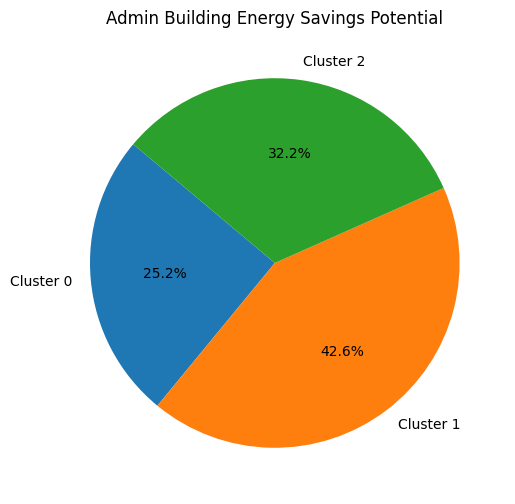

In [48]:
plt.figure(figsize=(6,6))
plt.pie(
    savings_cluster,
    labels=[f'Cluster {c}' for c in savings_cluster.index],
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Admin Building Energy Savings Potential")
plt.show()